
Jesus David Serpa Pajaro \\
cc:1192914660

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime

## 1. lectura de datos

### a) Haga la lectura del archivo y cambie los tipos de datos en cada columna a unos más apropiados para trabajar con ellos.



In [ ]:
#para leer el archivo, subimos el archivo de excel a la nube para poder leerlo por con pandas
url ="https://docs.google.com/spreadsheets/d/e/2PACX-1vTz3GxuzuSNlsMBXobBtOZrI1SBVPOUTHsnK-cZeGt2dJCFwq4pnB4UCuVbdcXQrTHeUkBWfUM4ZCU5/pub?output=csv"
df = pd.read_csv(url)
df = df.drop(['Unnamed: 1', 'Unnamed: 2'], axis=1)

df

,Date__(UT)__HR:MN,R.A._(ICRF),DEC__(ICRF)
0,2018-Jan-01 00:00,14 46 58.07,-15 09 25.8
1,2018-Jan-06 00:00,14 59 18.71,-16 05 26.8
2,2018-Jan-11 00:00,15 11 44.74,-16 58 42.1
3,2018-Jan-16 00:00,15 24 15.75,-17 49 01.5
4,2018-Jan-21 00:00,15 36 51.25,-18 36 15.1
...,...,...,...
288,2021-Dec-11 00:00,15 43 08.42,-19 37 45.2
289,2021-Dec-16 00:00,15 57 37.44,-20 25 24.8
290,2021-Dec-21 00:00,16 12 19.06,-21 08 45.9
291,2021-Dec-26 00:00,16 27 13.05,-21 47 32.6


In [ ]:

#Tomando en cuenta que los las componentes de a ascencion recta y la declinacion estan en tipo string hay que pasarlos de strig a flotante


#El sigueinte codigo lo que hace es coger cada termino a y ademas de pasarlo a flotante lo pasamos de grados min y seg a decimales,


# Ascencion recta
ar = []
for i in df.index:
  a = float(df['R.A._(ICRF)'][i].split(' ')[0])  + float(df['R.A._(ICRF)'][i].split(' ')[1]) /60 + float(df['R.A._(ICRF)'][i].split(' ')[2])/3600 # sumar cada termino, los seguos /60 y los minutos /3600 para dejarlo en grados
  ar.append(a)

# Declinacion
dcl = []
for i in df.index:
  if df["DEC__(ICRF)"][i][0]=='-': #garantizar que si es negativo cada elemento se resta para que de la suma negativa
    a =float(df['DEC__(ICRF)'][i].split(' ')[0])  - float(df['DEC__(ICRF)'][i].split(' ')[1]) /60 - float(df['DEC__(ICRF)'][i].split(' ')[2])/3600
    dcl.append(a)
  else:
    a =float(df['DEC__(ICRF)'][i].split(' ')[0])  + float(df['DEC__(ICRF)'][i].split(' ')[1]) /60 + float(df['DEC__(ICRF)'][i].split(' ')[2])/3600
    dcl.append(a)

#cambiar de string a datetime para la fecha

df['Date__(UT)__HR:MN'] = pd.to_datetime(df['Date__(UT)__HR:MN'])

#nuevos datos de la ascencion recta y la declinacion

print("Datos de la ascencion recta",ar)
print("Datos de la declinacion",dcl)

Datos de la ascencion recta [14.782797222222223, 14.988530555555554, 15.19576111111111, 15.404375, 15.614236111111111, 15.825208333333332, 16.037200000000002, 16.250127777777777, 16.463769444444445, 16.677813888888892, 16.891913888888887, 17.105766666666668, 17.319125, 17.531719444444445, 17.743122222222222, 17.952827777777777, 18.160327777777777, 18.36518888888889, 18.567072222222222, 18.765533333333334, 18.95996388888889, 19.149669444444445, 19.333966666666665, 19.5123, 19.684136111111112, 19.848719444444445, 20.005063888888888, 20.152047222222222, 20.288569444444445, 20.41365833333333, 20.526183333333332, 20.624661111111113, 20.707341666666665, 20.77240833333333, 20.818369444444443, 20.844130555555555, 20.848688888888887, 20.831319444444443, 20.792066666666667, 20.73241388888889, 20.655841666666664, 20.56731111111111, 20.47261111111111, 20.378119444444444, 20.29048611111111, 20.21625, 20.160916666666665, 20.127891666666667, 20.118666666666666, 20.133416666666665, 20.171572222222224,

In [ ]:
#Modificamos la tabla con los datos

#agregamos los nuevos datos de ascencion recta y declinacion a la tabla
df['R.A._(ICRF)']=ar
df['DEC__(ICRF)'] =dcl

df

,Date__(UT)__HR:MN,R.A._(ICRF),DEC__(ICRF)
0,2018-01-01,14.782797,-15.157167
1,2018-01-06,14.988531,-16.090778
2,2018-01-11,15.195761,-16.978361
3,2018-01-16,15.404375,-17.817083
4,2018-01-21,15.614236,-18.604194
...,...,...,...
288,2021-12-11,15.719006,-19.629222
289,2021-12-16,15.960400,-20.423556
290,2021-12-21,16.205294,-21.146083
291,2021-12-26,16.453625,-21.792389


### b)Realice gráficos de ascensión recta y de declinación contra tiempo. Discuta sobre lo observado y lo que esperaba observar.

#### ascencion recta y declinacion

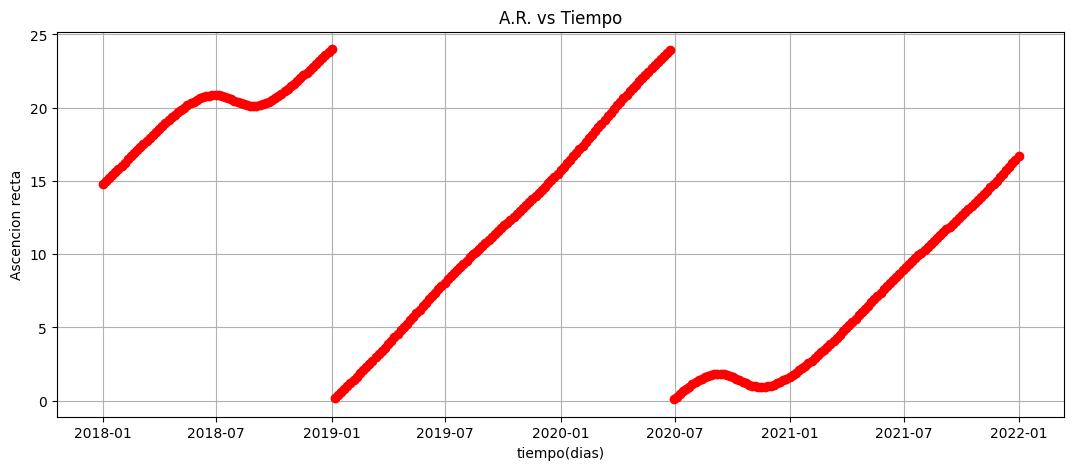

In [ ]:
# grafico ascencion recta vs tiempo
plt.figure(figsize=(13,5))
plt.plot(df['Date__(UT)__HR:MN'],df['R.A._(ICRF)'],"ro")
plt.xlabel("tiempo(dias)")
plt.ylabel("Ascencion recta")
plt.title("A.R. vs Tiempo")
plt.legend
plt.grid()

La grafica de la ascencion recta nos muestra un movimiento creciente,hasta que llega a su punto maximo y vuelve a empezar lo cual es esperado a diferencia de los momento de retrogradacion que empieza a decrecer y luego vuelve a su movimiento normal.

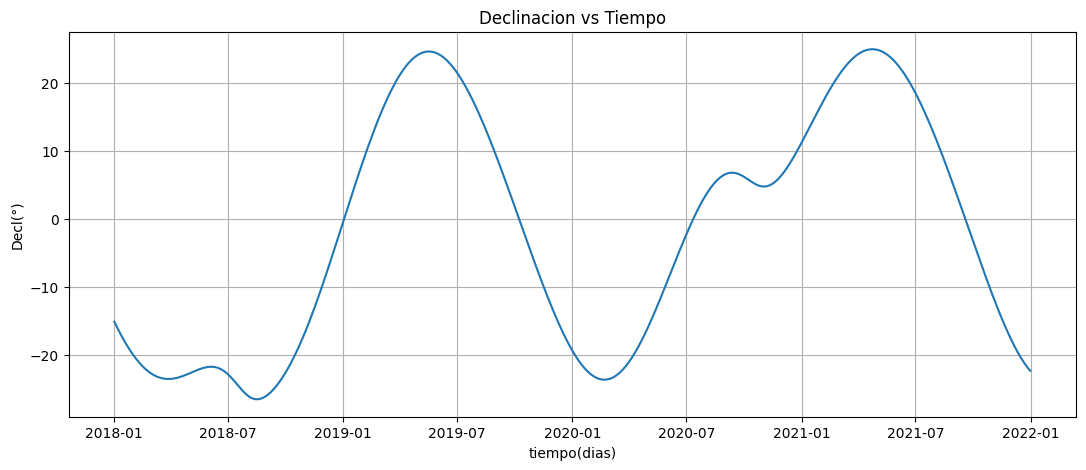

In [ ]:
#declinacion vs tiempo
plt.figure(figsize=(13,5))
plt.plot(df['Date__(UT)__HR:MN'],df['DEC__(ICRF)'],)
plt.xlabel("tiempo(dias)")
plt.ylabel("Decl(°)")
plt.title("Declinacion vs Tiempo")
plt.legend
plt.grid()

La grafica de la dechinacion nos muestra un movimiento senosoidal con un una aplitud relativamente constante lo cual es esperado de este movimiento a diferencia de los periodo de retrogradacion lo cuales en es momemto los valores actuan de manera contraria a como lleva su movimiento es decir que cuando disminuye en retorgradacion aumenta y viseversa, cuando aumenta en retrogradacion el valor disminuye

#### minimos y maximo declinacion

In [ ]:
#Maximos y minimos de la declinacion

#Maximos y minimo globales
Max=max(df['DEC__(ICRF)'])
Min=min(df['DEC__(ICRF)'])

print("Maximo global = ", Max )
print("Minimo global = ", Min)

# De acuerdo a la grafica es muy mas sencillo escoger las zonas donde puede  haber un punto maximo o un punto minimo en una zona especifica
#Maximos y minimos locales

minimosdcl=[] #lista para los minimos locales
maximosdcl=[] #lista pra los maximos locales
fechasmaxdcl=[] #lista donde se archiva en que fecha esta el maximo local
fechasmindcl=[] #lista donde se archiva en que fecha esta el minimo local
x=df['DEC__(ICRF)']

#para eso generamos un codigo para que al pasar por cada datos verifique que el numero inmediatamente anterior y siguiente tambien sea menor se cumpla para que sea un maximo local
for i in range(1, len(x)-1):
    if x[i] > x[i-1] and x[i] > x[i+1]:
        maximosdcl.append(x[i])
        fecha=df['Date__(UT)__HR:MN'][i]
        fechasmaxdcl.append(fecha)


# El mismo procedimiento que el anterior pero que el numero antes y despues sean mayores para que sea un minimo local
for i in range(1, len(x)-1):
    if x[i] < x[i-1] and x[i] < x[i+1]:
        minimosdcl.append(x[i])
        fecha=df['Date__(UT)__HR:MN'][i]
        fechasmindcl.append(fecha)

#imprimimons los minimos y maximos locales con sus fechas
for i in range(len(fechasmindcl)):
  print("Minimo",i+1, "de valor minimo ", minimosdcl[i], "esta en la fecha ",fechasmindcl[i])
  print("Maximo",i+1, "de valor maximo ", maximosdcl[i], "esta en la fecha ",fechasmaxdcl[i])

Maximo global =  24.89311111111111
Minimo global =  -26.540805555555558
Minimo 1 de valor minimo  -23.563861111111112 esta en la fecha  2018-03-27 00:00:00
Maximo 1 de valor maximo  -21.765333333333334 esta en la fecha  2018-06-05 00:00:00
Minimo 2 de valor minimo  -26.540805555555558 esta en la fecha  2018-08-14 00:00:00
Maximo 2 de valor maximo  24.558666666666667 esta en la fecha  2019-05-16 00:00:00
Minimo 3 de valor minimo  -23.673944444444444 esta en la fecha  2020-02-20 00:00:00
Maximo 3 de valor maximo  6.7564166666666665 esta en la fecha  2020-09-12 00:00:00
Minimo 4 de valor minimo  4.709805555555556 esta en la fecha  2020-11-01 00:00:00
Maximo 4 de valor maximo  24.89311111111111 esta en la fecha  2021-04-25 00:00:00


Con esto vemos que el maximo global corresponde al cuarto maximo local y el minimo global  al segundo minimo local

### c)Utilice los datos proporcionados para calcular las coordenadas eclípticas y
galácticas de Marte durante las observaciones.

In [ ]:
rad = np.pi/180
grad = 180/np.pi

#### Coordenadas eclípticas

In [ ]:
#transformar de ecuatoriales a eclipticas
def ecua2eclip(asr, decl):
  asr=asr*rad
  decl=decl*rad

  e = (23+26/60)*rad

  #Para lla hallar la latitud ecliptica
  B = np.arcsin(np.sin(decl)*np.cos(e) - np.cos(decl)*np.sin(e)*np.sin(asr))

  #Para hallar la longitud ecliptica
  p = np.sin(asr)*np.sin(e) + np.cos(decl)*np.cos(e)*np.sin(asr)
  q = np.cos(asr)*np.cos(decl)
  lamda = np.arctan(p/q)
  if p*q<0 and q<0:
    lamda = lamda + np.pi
  elif p*q and q>0:
    lamda = lamda + 2*np.pi
  elif p+q<0:
    lamda = lamda + np.pi

  if lamda>2*np.pi:
    lamda = lamda -2*np.pi
  if lamda<0:
    lamda = lamda + 2*np.pi

  B=B*grad
  lamda=lamda*grad
  return(B,lamda)


In [ ]:
#evaluar hacer la conversion

β=[] #latitud ecliptica
λ=[] #longitud ecliptica

for i in range(len(df['Date__(UT)__HR:MN'])):
  asr=df['R.A._(ICRF)'][i]*15
  dcl= df['DEC__(ICRF)'][i]
  (B,lamda)=ecua2eclip(asr,dcl)
  β.append(B)
  λ.append(lamda)

In [ ]:
df['longitud Eclip.']=λ
df["latitud Eclip."]=β
df

,Date__(UT)__HR:MN,R.A._(ICRF),DEC__(ICRF),longitud Eclip.,latitud Eclip.
0,2018-01-01,14.782797,-15.157167,229.871097,0.896943
1,2018-01-06,14.988531,-16.090778,232.925238,0.863691
2,2018-01-11,15.195761,-16.978361,235.909295,0.827676
3,2018-01-16,15.404375,-17.817083,238.823882,0.788615
4,2018-01-21,15.614236,-18.604194,241.670369,0.746384
...,...,...,...,...,...
288,2021-12-11,15.719006,-19.629222,243.090134,0.087094
289,2021-12-16,15.960400,-20.423556,246.220841,0.035934
290,2021-12-21,16.205294,-21.146083,249.301610,-0.016245
291,2021-12-26,16.453625,-21.792389,252.338395,-0.069507


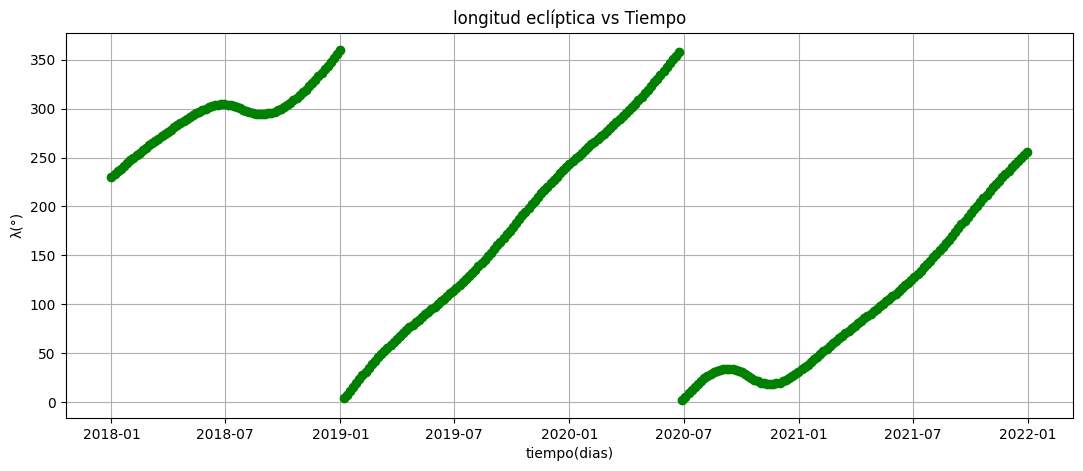

In [ ]:
# grafico longitud ecliptica vs tiempo
plt.figure(figsize=(13,5))
plt.plot(df['Date__(UT)__HR:MN'],df['longitud Eclip.'],"go")
plt.xlabel("tiempo(dias)")
plt.ylabel("λ(°)")
plt.title("longitud eclíptica vs Tiempo")
plt.legend
plt.grid()

La longitud ecliptica tiene un movimiento similar al de la ascension recta, un movimiento creciente a diferencia de los momentos de retrogradación.

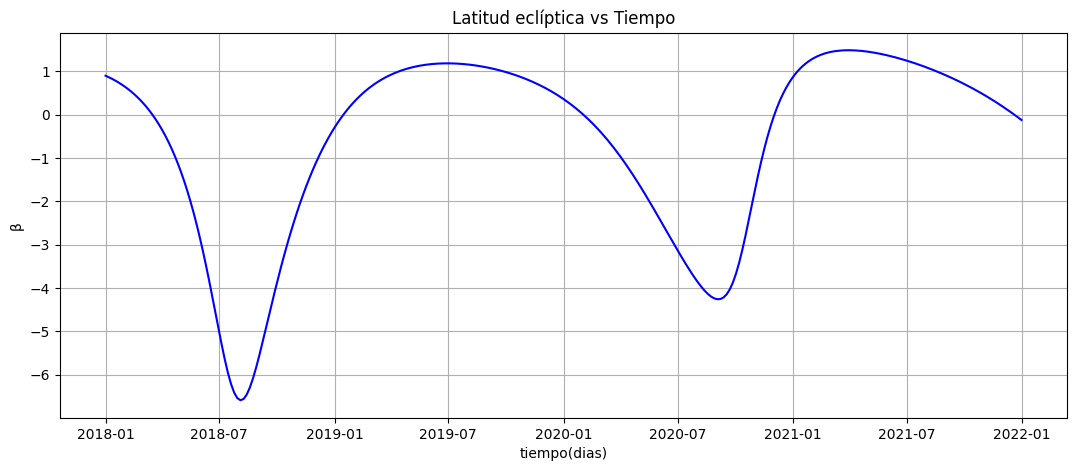

In [ ]:
# grafico latitud ecliptica vs tiempo
plt.figure(figsize=(13,5))
plt.plot(df['Date__(UT)__HR:MN'],df['latitud Eclip.'],"b")
plt.xlabel("tiempo(dias)")
plt.ylabel("β")
plt.title("Latitud eclíptica vs Tiempo")
plt.legend
plt.grid()

La latitud ecliptica a diferencia de la declinacion, como siguen siendo datos aparentes, el comportamiento de oscilacion cambia mucho mas en terminos de las amplitudes. y lo cual es afectado tambien que en las caidas de valores es cuando se presenta la retrogradacion.

##### minimos y maximos latitud ecliptica

In [ ]:
#Maximos y minimos de la Latitud ecliptica

#Maximos y minimo globales
Max=max(df['latitud Eclip.'])
Min=min(df['latitud Eclip.'])

print("Maximo global = ", Max )
print("Minimo global = ", Min)

# De acuerdo a la grafica es muy mas sencillo escoger las zonas donde puedeb haber un punto maximo o un punto minimo en una zona especifica
#Maximos y minimos locales

minimosecl=[]
maximosecl=[]
fechasmaxecl=[]
fechasminecl=[]
x=df['latitud Eclip.']

#para eso generamos un codigo para que al pasar por cada datos verifique que el numero inmediatamente anterior y siguiente tambien sea menor se cumpla para que sea un maximo local
for i in range(1, len(x)-1):
    if x[i] > x[i-1] and x[i] > x[i+1]:
        maximosecl.append(x[i])
        fecha=df['Date__(UT)__HR:MN'][i]
        fechasmaxecl.append(fecha)

for i in range(len(fechasminecl)):
  print("Maximo",i+1," de valor maximo ",maximosecl[i], "esta en la fecha ",fechasmaxecl[i])

# El mismo procedimiento que el anterior pero que el numero antes y despues sean mayores para que sea un minimo local
for i in range(1, len(x)-1):
    if x[i] < x[i-1] and x[i] < x[i+1]:
        minimosecl.append(x[i])
        fecha=df['Date__(UT)__HR:MN'][i]
        fechasminecl.append(fecha)

#maximos y minimos locales
for i in range(len(fechasminecl)):
  print("Minimo ",i+1, "de valor minimo", minimosecl[i], "esta en la fecha ",fechasminecl[i])
  print("Maximo ",i+1, "de valor maximo",maximosecl[i] , "esta en la fecha ",fechasmaxecl[i])

Maximo global =  1.4849874801174896
Minimo global =  -6.5853671218921725
Minimo  1 de valor minimo -6.5853671218921725 esta en la fecha  2018-08-04 00:00:00
Maximo  1 de valor maximo 1.182395114214888 esta en la fecha  2019-06-30 00:00:00
Minimo  2 de valor minimo -4.256512697512595 esta en la fecha  2020-09-02 00:00:00
Maximo  2 de valor maximo 1.4849874801174896 esta en la fecha  2021-03-31 00:00:00


A partir de esto podemos ver que el maximo global es igual al maximo local 1, y el minimos global es el minimos local 1

#### Coordenadas galacticas

In [ ]:
#definimos una funcion para la tranformacion de coordenadas ecuatoriasles a eclipticas

# Transformacion de ecuatoriales a Galacticas
def ecua2galac(asr,decl):
  asr=asr*rad
  decl=decl*rad

  asrpg = (12+51.4/60)*15*rad
  declpg = (27+8/60)*rad
  ln=123*rad

  #Para hallar latitud galactica
  b = np.arcsin(np.sin(decl)*np.sin(declpg)+np.cos(decl)*np.cos(declpg)*np.cos(asr-asrpg))

  #Para hallar la longitud galactica

  #definimos la tangente a la -1
  p = np.cos(decl)*np.sin(asr-asrpg)
  q = np.sin(decl)*np.cos(declpg) - np.sin(declpg)*np.cos(decl)*np.cos(asr-asrpg)
  gamma = np.arctan(p/q)
  if p*q<0 and q<0:
    gamma = gamma + np.pi
  elif p*q<0 and q>0:
    gamma = gamma + 2*np.pi
  elif p+q<0:
    gamma = gamma + np.pi
  #formula para la longitud galactica
  l = ln - gamma

  if l<0: #la longitud debe ser siempre positiva
    l = l + 2*np.pi
  if l>360: #la longitud no puede medir mas de 360
    l = l - 2*np.pi


  l=l*grad
  b=b*grad
  return(l,b)


In [ ]:
#evaluar hacer la conversion

l=[] #latitud ecliptica
b=[] #longitud ecliptica

for i in range(len(df['Date__(UT)__HR:MN'])):
  asr=df['R.A._(ICRF)'][i]*15
  dcl= df['DEC__(ICRF)'][i]
  (x,y)=ecua2galac(asr,dcl)
  l.append(x)
  b.append(y)

In [ ]:
df['longitud Galact.']=l
df["latitud Galact."]=b
df

,Date__(UT)__HR:MN,R.A._(ICRF),DEC__(ICRF),longitud Eclip.,latitud Eclip.,longitud Galact.,latitud Galact.
0,2018-01-01,14.782797,-15.157167,229.871097,0.896943,340.034279,39.258959
1,2018-01-06,14.988531,-16.090778,232.925238,0.863691,342.450876,36.792823
2,2018-01-11,15.195761,-16.978361,235.909295,0.827676,344.710918,34.285480
3,2018-01-16,15.404375,-17.817083,238.823882,0.788615,346.833164,31.745003
4,2018-01-21,15.614236,-18.604194,241.670369,0.746384,348.834370,29.178626
...,...,...,...,...,...,...,...
288,2021-12-11,15.719006,-19.629222,243.090134,0.087094,349.284024,27.418308
289,2021-12-16,15.960400,-20.423556,246.220841,0.035934,351.383237,24.478557
290,2021-12-21,16.205294,-21.146083,249.301610,-0.016245,353.394518,21.497108
291,2021-12-26,16.453625,-21.792389,252.338395,-0.069507,355.332853,18.477751


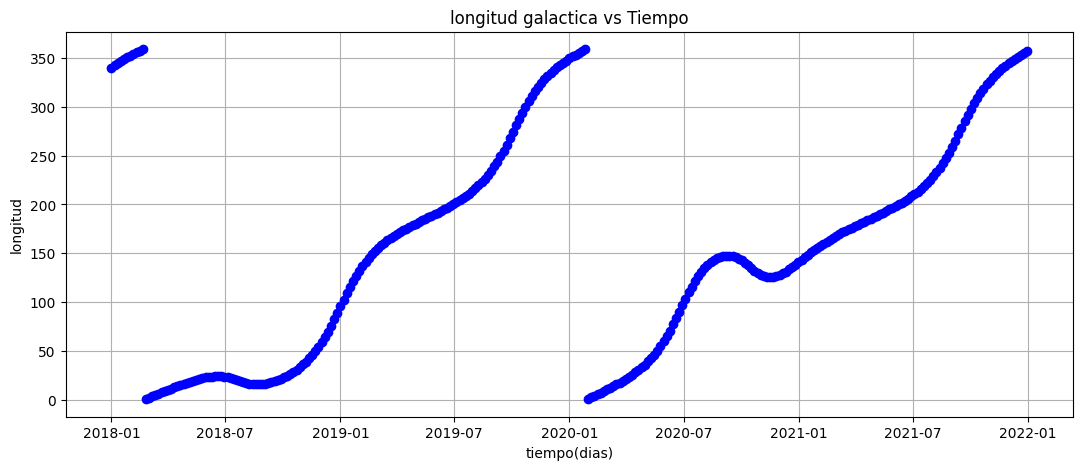

In [ ]:
# grafico longitud galactica vs tiempo
plt.figure(figsize=(13,5))
plt.plot(df['Date__(UT)__HR:MN'],df['longitud Galact.'],"bo")
plt.xlabel("tiempo(dias)")
plt.ylabel("longitud")
plt.title("longitud galactica vs Tiempo")
plt.legend
plt.grid()

el comportamiento de la latitud galactica se debe a que los datos son aparentes se ve un movimiento un poco cambiante, tiene a curvearse, pero, sigue siendo un aumento creciente a excepcion de los momentos de retrogradacion como lo explicado anteriormente.

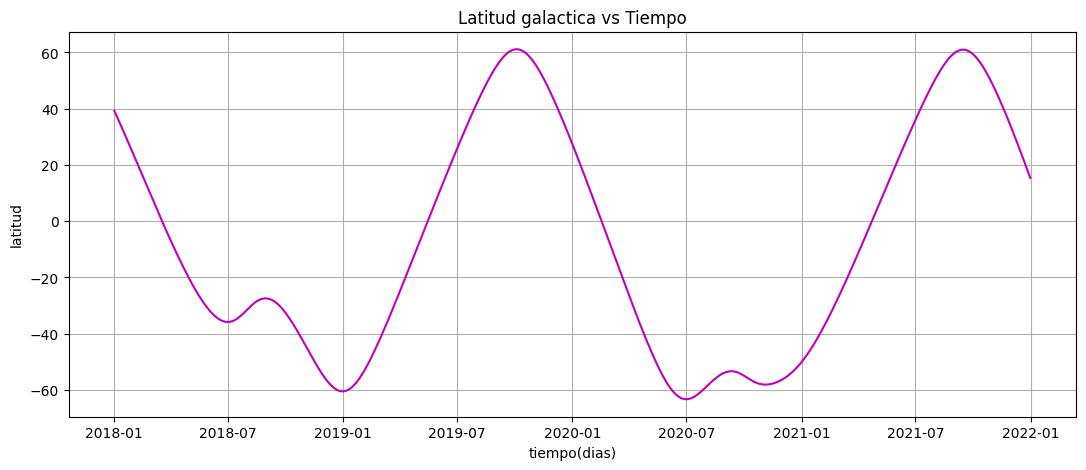

In [ ]:
# grafico latitud galactica vs tiempo
plt.figure(figsize=(13,5))
plt.plot(df['Date__(UT)__HR:MN'],df['latitud Galact.'],"m")
plt.xlabel("tiempo(dias)")
plt.ylabel("latitud")
plt.title("Latitud galactica vs Tiempo")
plt.legend
plt.grid()

La latitud galactica tiene un comportamiento parecido a la declinacion en termino de tiempo de moviemto y comportamiento en periodo de retrogadacion, evidentemente con cambios en los valores de amplitud y eso.

##### minimos y maximos latitud galactica

In [ ]:
#Maximos y minimos de la latitud Galactica

#Maximos y minimo globales
Max=max(df['latitud Galact.'])
Min=min(df['latitud Galact.'])

print("Maximo global = ", Max )
print("Minimo global = ", Min)

# De acuerdo a la grafica es muy mas sencillo escoger las zonas donde puedeb haber un punto maximo o un punto minimo en una zona especifica
#Maximos y minimos locales

minimosgal=[]
maximosgal=[]
fechasmaxgal=[]
fechasmingal=[]
x=df['latitud Galact.']

lugaresmin=[]
lugaresmax=[]
#para eso generamos un codigo para que al pasar por cada datos verifique que el numero inmediatamente anterior y siguiente tambien sea menor se cumpla para que sea un maximo local
for i in range(1, len(x)-1):
    if x[i] > x[i-1] and x[i] > x[i+1]:
        maximosgal.append(x[i])
        fecha=df['Date__(UT)__HR:MN'][i]
        fechasmaxgal.append(fecha)
        lugaresmax.append(i)


# El mismo procedimiento que el anterior pero que el numero antes y despues sean mayores para que sea un minimo local
for i in range(1, len(x)-1):
  if x[i] < x[i-1] and x[i] < x[i+1]:
      minimosgal.append(x[i])
      fecha=df['Date__(UT)__HR:MN'][i]
      fechasmingal.append(fecha)
      lugaresmin.append(i)



#minimos y maximos locales
for i in range(len(fechasmingal)):
  print("Minimo",i+1, "de valor minimo", minimosgal[i], "esta en la fecha ",fechasmingal[i])
  print("Maximo",i+1," de valor maximo",maximosgal[i], "esta en la fecha ",fechasmaxgal[i])

Maximo global =  61.14395081145017
Minimo global =  -63.269858640145245
Minimo 1 de valor minimo -35.829673684936395 esta en la fecha  2018-06-30 00:00:00
Maximo 1  de valor maximo -27.410230011988112 esta en la fecha  2018-08-29 00:00:00
Minimo 2 de valor minimo -60.48432536146999 esta en la fecha  2019-01-01 00:00:00
Maximo 2  de valor maximo 61.14395081145017 esta en la fecha  2019-10-03 00:00:00
Minimo 3 de valor minimo -63.269858640145245 esta en la fecha  2020-06-29 00:00:00
Maximo 3  de valor maximo -53.31624739155656 esta en la fecha  2020-09-12 00:00:00
Minimo 4 de valor minimo -58.061804989420494 esta en la fecha  2020-11-06 00:00:00
Maximo 4  de valor maximo 60.976777727428505 esta en la fecha  2021-09-17 00:00:00


de acuerdo a esto podemos ver que el maximo global corresponde al maximo local 2 y el minimos global corresponde al minimo local 3

### d) los puntos donde el planeta cruza los respectivos planos de referencia de cada coordenada.












El procedimiento para poder encontrar en que dai exacto el planeta marte corto cada plano de refencia consiste en el siguiente procedimiento

*   Primero sacar las fechas y los valores inmediatamente antes y despues de cuando cruza el plano de referencia
*   Apartir de esto como sabemos que el tiempo entre un punto y otro es de 5 dias podemos sacar la velocidad que tiene con la distancia recorrida de los dos puntos.
*   Con la velocidad ya podemos hallar cuanto tiempo se demora desde el punto antes de cruzar el plano de referencia hasta que se encuentra en el plano
*   Con este tiempo lo pasamos a dias y se lo sumamos a la fecha y nos da el momento exacto donde se encuentra en el plano de refencia





In [ ]:
# puntos dodne el planeta cruzaba los respectivos planos de referencia

#para el plano galactico
x=df['latitud Galact.']
fechas1=[]
fechanext1=[]

#sacamos los puntos de la latitud donde el planeta pasa por el plano de refencia entre esos puntos
puntos=[]
puntosnext=[]

for i in range(0, len(x)-1):
    if  x[i]*x[i+1] <0: #verifico el cambio de signo
        puntos.append(x[i])
        puntosnext.append(x[i+1])
        fecha=df['Date__(UT)__HR:MN'][i]
        next=df['Date__(UT)__HR:MN'][i+1]
        fechas1.append(fecha)
        fechanext1.append(next)

for i in range(len(puntos)):
  print('Entre las fechas', fechas1[i], 'y', fechanext1[i],' marte cruza el plano galactico')


Entre las fechas 2018-03-17 00:00:00 y 2018-03-22 00:00:00  marte cruza el plano galactico
Entre las fechas 2019-05-11 00:00:00 y 2019-05-16 00:00:00  marte cruza el plano galactico
Entre las fechas 2020-02-15 00:00:00 y 2020-02-20 00:00:00  marte cruza el plano galactico
Entre las fechas 2021-04-20 00:00:00 y 2021-04-25 00:00:00  marte cruza el plano galactico


In [ ]:
print(puntos,puntosnext)

[0.5727164045010928, -2.566586184323348, 1.0422336531783243, -1.3689868868235502] [-1.9557809234702417, 0.2461010533626079, -1.9782063624700064, 1.2548633830422264]


In [ ]:
#realizamos una aproximacion para calcular mas o menos en que fecha exacta para por el plano de referencia

#Como las fechas son muy cercanas podemos hacer una aproximacion de la velocidad angular

#los dias que pasan entre los datos es de 5 dias
Δdias=5

d1=[] #distancia recorrida
w1=[] #velocidad angular
t=[]  #tiempo en dias

for i in range(len(puntos)):
  d= puntos[i] - puntosnext[i]
  d1.append(abs(d))

  #velocidad angular
  w=d1[i]/Δdias
  w1.append(w)

  #sacamos los dias que han pasados desde punto anterior hasta el plano


  x = puntos[i]/w1[i]
  t.append(abs(x))

print(w1,t)


[0.5056994655942668, 0.5625374475371913, 0.604088003129666, 0.5247700539731553] [1.1325232543563633, 4.562516141031948, 1.72530102862283, 2.6087366770619513]


In [ ]:
dias1=[]
for i in range(len(t)):
  dias = pd.Timedelta(days=t[i])
  dias1.append(dias)

dias1

[Timedelta('1 days 03:10:50.009176389'),
 Timedelta('4 days 13:30:01.394585160'),
 Timedelta('1 days 17:24:26.008873012'),
 Timedelta('2 days 14:36:34.848898152')]

In [ ]:
#el planeta cruzara el plano galactico aproximadamente en
day=[]
for i in range(len(puntos)):
  da=fechas1[i] + dias1[i]
  day.append(da)


for i in range(len(day)):
  print("Marte pasa por el plano galactico el:",day[i])

Marte pasa por el plano galactico el: 2018-03-18 03:10:50.009176389
Marte pasa por el plano galactico el: 2019-05-15 13:30:01.394585160
Marte pasa por el plano galactico el: 2020-02-16 17:24:26.008873012
Marte pasa por el plano galactico el: 2021-04-22 14:36:34.848898152


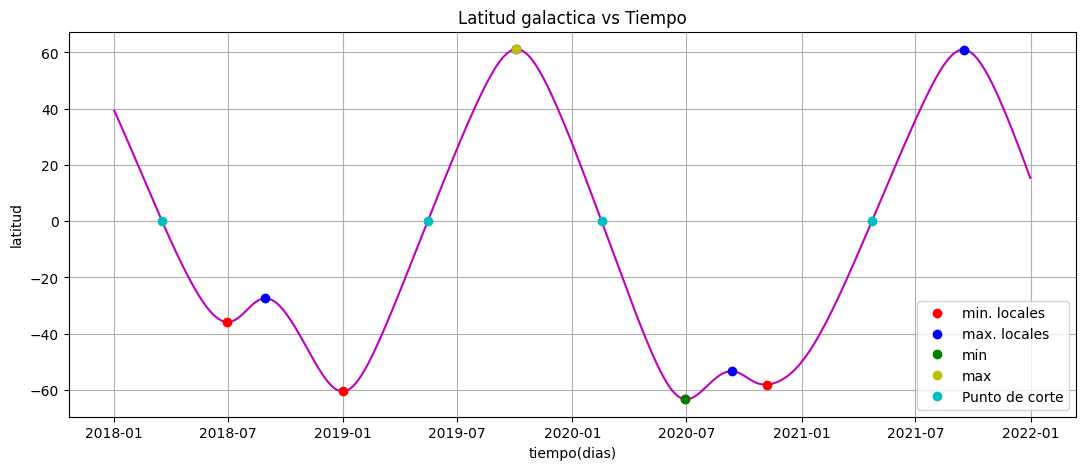

In [ ]:
# grafico latitud galactica vs tiempo
plt.figure(figsize=(13,5))
plt.plot(df['Date__(UT)__HR:MN'],df['latitud Galact.'],"m")
plt.xlabel("tiempo(dias)")
plt.ylabel("latitud")
plt.title("Latitud galactica vs Tiempo")

#graficamos los minimos y maximos locales

plt.plot(fechasmingal,minimosgal,"ro",label="min. locales")
plt.plot(fechasmaxgal,maximosgal,"bo",label="max. locales")

#graficamos el maximo y el minimo

plt.plot(fechasmingal[2],minimosgal[2],"go",label="min")
plt.plot(fechasmaxgal[1],maximosgal[1],"yo",label="max")

#momentos donde pasa por el plano galactico
cero=[0]*4
plt.plot(day,cero,"co",label="Punto de corte")

plt.legend()
plt.grid()

In [ ]:
#para la ecliptica
x=df['latitud Eclip.']
fechas2=[]
fechanext2=[]

puntos2=[]
puntosnext2=[]

for i in range(0, len(x)-1):
    if  x[i]*x[i+1] <0: #verifico el cambio de signo
        puntos2.append(x[i])
        puntosnext2.append(x[i+1])
        fecha=df['Date__(UT)__HR:MN'][i]
        next=df['Date__(UT)__HR:MN'][i+1]
        fechas2.append(fecha)
        fechanext2.append(next)


for i in range(len(puntos2)):
  print('Entre las fechas', fechas2[i], 'y', fechanext2[i],' marte cruza la ecliptica')

Entre las fechas 2018-03-12 00:00:00 y 2018-03-17 00:00:00  marte cruza la ecliptica
Entre las fechas 2019-01-11 00:00:00 y 2019-01-16 00:00:00  marte cruza la ecliptica
Entre las fechas 2020-01-31 00:00:00 y 2020-02-05 00:00:00  marte cruza la ecliptica
Entre las fechas 2020-12-01 00:00:00 y 2020-12-06 00:00:00  marte cruza la ecliptica
Entre las fechas 2021-12-16 00:00:00 y 2021-12-21 00:00:00  marte cruza la ecliptica


In [ ]:
#realizamos una aproximacion para calcular mas o menos en que fecha exacta para por el plano de referencia

#Como las fechas son muy cercanas podemos hacer una aproximacion de la velocidad angular

#los dias que pasan entre los datos es de 5 dias
Δdias=5

d2=[] #distancia recorrida
w2=[] #velocidad angular
t2=[]  #tiempo en dias

for i in range(len(puntos2)):
  d= puntos2[i] - puntosnext2[i]
  d2.append(abs(d))

  #velocidad angular
  w=d2[i]/Δdias
  w2.append(w)

  #sacamos los dias que han pasados desde punto anterior hasta el plano

  x = puntos2[i]/w2[i]
  t2.append(abs(x))

print(w2,t2)


[0.019485291621378516, 0.019683737882577136, 0.013048140712780747, 0.03971813339721811, 0.010435784542087012] [4.603134460823058, 4.2026825673500525, 1.4957879496437252, 1.1817816356513038, 3.44337704792192]


In [ ]:
dias2=[]
for i in range(len(t2)):
  dias = pd.Timedelta(days=t2[i])
  dias2.append(dias)

dias2

[Timedelta('4 days 14:28:30.817415112'),
 Timedelta('4 days 04:51:51.773819044'),
 Timedelta('1 days 11:53:56.078849217'),
 Timedelta('1 days 04:21:45.933320272'),
 Timedelta('3 days 10:38:27.776940453')]

In [ ]:
#el planeta cruzara la ecliptica aproximadamente en
day2=[]
for i in range(len(puntos2)):
  da=fechas2[i] + dias2[i]
  day2.append(da)

for i in range(len(day2)):
  print("Marte pasa por la ecliptica el:",day2[i])

Marte pasa por la ecliptica el: 2018-03-16 14:28:30.817415112
Marte pasa por la ecliptica el: 2019-01-15 04:51:51.773819044
Marte pasa por la ecliptica el: 2020-02-01 11:53:56.078849217
Marte pasa por la ecliptica el: 2020-12-02 04:21:45.933320272
Marte pasa por la ecliptica el: 2021-12-19 10:38:27.776940453


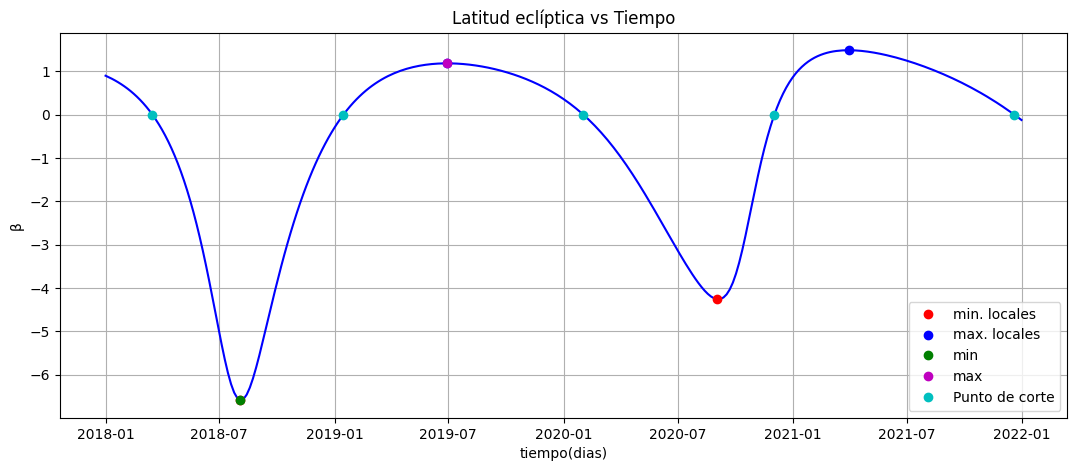

In [ ]:
#declinacion vs tiempo
plt.figure(figsize=(13,5))
plt.plot(df['Date__(UT)__HR:MN'],df['latitud Eclip.'],"b")
plt.xlabel("tiempo(dias)")
plt.ylabel("β")
plt.title("Latitud eclíptica vs Tiempo")

#graficamos los minimos y maximos locales
plt.plot(fechasminecl,minimosecl,"ro",label="min. locales")
plt.plot(fechasmaxecl,maximosecl,"bo",label="max. locales")

#graficamos el maximo y el minimo
plt.plot(fechasminecl[0],minimosecl[0],"go",label="min")
plt.plot(fechasmaxecl[0],maximosecl[0],"mo",label="max")

#momentos donde pasa por el la ecliptica
cero=[0]*5
plt.plot(day2,cero,"co",label="Punto de corte")

plt.legend()
plt.grid()

In [ ]:
#para el ecuador celeste
x=df['DEC__(ICRF)']
fechas3=[]
fechanext3=[]

puntos3=[]
puntosnext3=[]


for i in range(0, len(x)-1):
    if  x[i]*x[i+1] <0: #verifico el cambio de signo
        puntos3.append(x[i])
        puntosnext3.append(x[i+1])
        fecha=df['Date__(UT)__HR:MN'][i]
        next=df['Date__(UT)__HR:MN'][i+1]
        fechas3.append(fecha)
        fechanext3.append(next)

for i in range(len(puntos3)):
  print('Entre las fechas', fechas3[i], 'y', fechanext3[i],' marte cruza el ecuador celeste')

Entre las fechas 2019-01-01 00:00:00 y 2019-01-06 00:00:00  marte cruza el ecuador celeste
Entre las fechas 2019-10-08 00:00:00 y 2019-10-13 00:00:00  marte cruza el ecuador celeste
Entre las fechas 2020-07-09 00:00:00 y 2020-07-14 00:00:00  marte cruza el ecuador celeste
Entre las fechas 2021-09-17 00:00:00 y 2021-09-22 00:00:00  marte cruza el ecuador celeste


In [ ]:
#realizamos una aproximacion para calcular mas o menos en que fecha exacta para por el plano de referencia

#Como las fechas son muy cercanas podemos hacer una aproximacion de la velocidad angular

#los dias que pasan entre los datos es de 5 dias
Δdias=5

d3=[] #distancia recorrida
w3=[] #velocidad angular
t3=[]  #tiempo en dias

for i in range(len(puntos3)):
  d= puntos3[i] - puntosnext3[i]
  d3.append(abs(d))

  #velocidad angular
  w=d3[i]/Δdias
  w3.append(w)

  #sacamos los dias que han pasados desde punto anterior hasta el plano

  x = puntos3[i]/w3[i]
  t3.append(abs(x))

print(w3,t3)


[0.28792777777777784, 0.2602111111111111, 0.19803888888888888, 0.2638388888888889] [1.4001389237270148, 0.0021350185746615994, 3.1071338401548516, 1.2983512665557684]


In [ ]:
dias3=[]
for i in range(len(t3)):
  dias = pd.Timedelta(days=t3[i])
  dias3.append(dias)

dias3

[Timedelta('1 days 09:36:12.003010014'),
 Timedelta('0 days 00:03:04.465604850'),
 Timedelta('3 days 02:34:16.363789379'),
 Timedelta('1 days 07:09:37.549430418')]

In [ ]:
#el planeta cruzara el ecuador celeste aproximadamente en
day3=[]
for i in range(len(puntos3)):
  da=fechas3[i] + dias3[i]
  day3.append(da)

for i in range(len(day3)):
  print("Marte pasa por el ecuador celeste el:",day3[i])

Marte pasa por el ecuador celeste el: 2019-01-02 09:36:12.003010014
Marte pasa por el ecuador celeste el: 2019-10-08 00:03:04.465604850
Marte pasa por el ecuador celeste el: 2020-07-12 02:34:16.363789379
Marte pasa por el ecuador celeste el: 2021-09-18 07:09:37.549430418


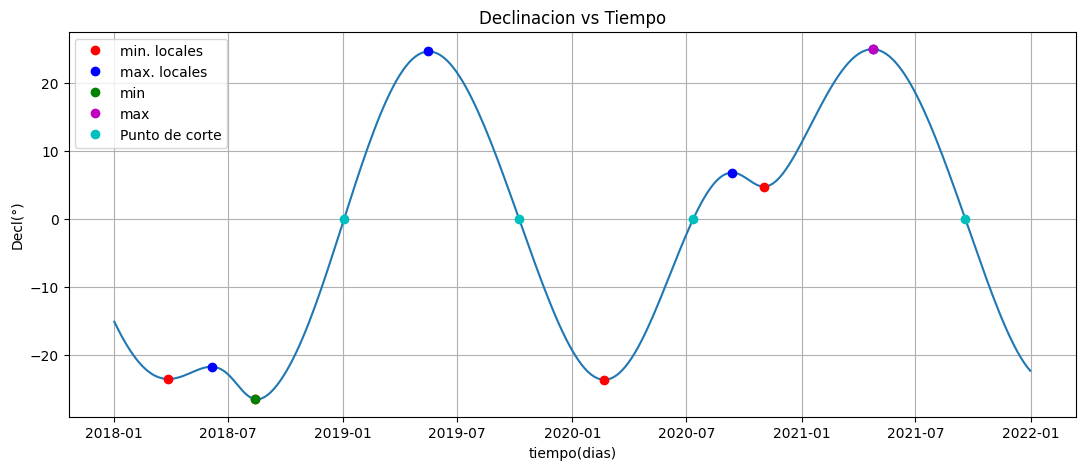

In [ ]:
#declinacion vs tiempo
plt.figure(figsize=(13,5))
plt.plot(df['Date__(UT)__HR:MN'],df['DEC__(ICRF)'],)
plt.xlabel("tiempo(dias)")
plt.ylabel("Decl(°)")
plt.title("Declinacion vs Tiempo")


#graficamos los minimos y maximos locales
plt.plot(fechasmindcl,minimosdcl,"ro",label="min. locales")
plt.plot(fechasmaxdcl,maximosdcl,"bo",label="max. locales")

#graficamos el maximo y el minimo
plt.plot(fechasmindcl[1],minimosdcl[1],"go",label="min")
plt.plot(fechasmaxdcl[3],maximosdcl[3],"mo",label="max")

#momentos donde pasa por el la ecuador celeste
cero=[0]*4
plt.plot(day3,cero,"co",label="Punto de corte")

plt.legend()
plt.grid()

## 2. Estudio del movimiento aparente del planeta y de su trayectoria

### a) Seleccione dos observaciones separadas por 30-40 días entre las cuales el planeta haya cruzado la eclíptica. Utilice trigonometría esférica para calcular la distancia angular aparente recorrida por el planeta entre estas observaciones.
Use este resultado para calcular también su velocidad angular aparente.

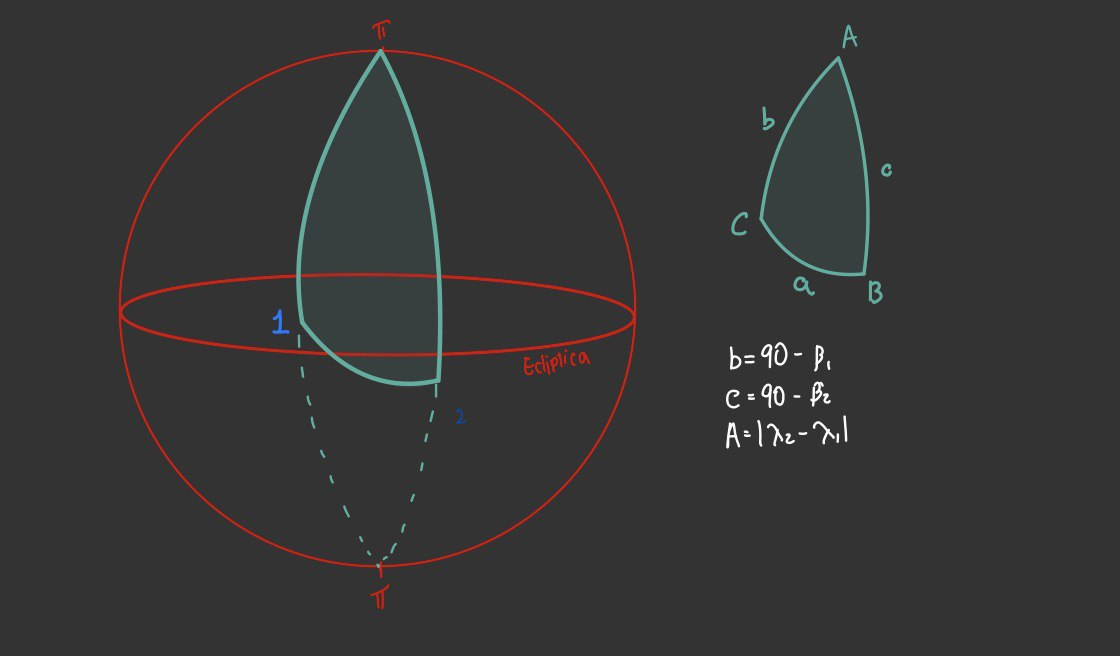

In [ ]:
#ecogemos dos puntos por los cuales pasan por la ecliptica, es decir cogemos dos puntos con sus coordenadas ecuatoriales ambos separados 30dias


β=df['latitud Eclip.'][12]
λ=df['longitud Eclip.'][12]

print(df['Date__(UT)__HR:MN'][12])
print(df['Date__(UT)__HR:MN'][18])

print('Latitud del punto 1:',β,'Longitud del punto 1:',λ)

β2=df['latitud Eclip.'][18]
λ2=df['longitud Eclip.'][18]
print('Latitud del punto 2:',β2,'Longitud del punto 2:',λ2)


2018-03-02 00:00:00
2018-04-01 00:00:00
Latitud del punto 1: 0.26356074557527026 Longitud del punto 1: 262.39307793757746
Latitud del punto 2: -0.34795534835354436 Longitud del punto 2: 276.3154995503604


In [ ]:
#defimos una funcion que nos resulva el valor que necesitamos de el triangulo esferico
def dist_2puntos(ϕ,λ,ϕ_,λ_):
  b = 90 - ϕ_
  c = 90 - ϕ
  A = abs(λ_ - λ)
  a = np.arccos( (np.cos(b*rad)*np.cos(c*rad) + np.sin(b*rad)*np.sin(c*rad)*np.cos(A*rad)) )  #teorema dl coseno
  return a *grad

In [ ]:
#evaluamos para sacar el lado que necesitamos la cual correspone lo que trancurrio de un punto a otro

ladoa= dist_2puntos(β,λ,β2,λ2)
print('La distancia entre los dos puntos es de=', ladoa,'º')

La distancia entre los dos puntos es de= 13.935775113615687 º


In [ ]:
#Calculamos su velocidad angular aparente

W= ladoa/30

print('La velociada aparente sera de ',W,'º/dia')

La velociada aparente sera de  0.4645258371205229 º/dia


### b) Con la información del apartado anterior, calcule el angulo entre la trayectoria aparente del planeta y la eclıptica (utilice nuevamente sus conocimientos en trigonometrıa esférica).

In [ ]:
#tomando en cuenta que para el nuevo triangulo, el angulo B se puede sacar a partir de los datos del primer triangulo, usamos los mismo datos y la funcion agregando para calcular el angulo B
def dist_2puntos2(ϕ,λ,ϕ_,λ_):
  b = 90 - ϕ_
  c = 90 - ϕ
  A = abs(λ_ - λ)
  a = np.arccos( (np.cos(b*rad)*np.cos(c*rad) + np.sin(b*rad)*np.sin(c*rad)*np.cos(A*rad)) )  #teorema dl coseno

  x = np.cos(a)*np.cos(c*rad)
  y = np.sin(a)*np.sin(c*rad)

  B = np.arccos( (np.cos(b*rad) - x)/y)

  return B *grad

In [ ]:
#evaluamos para sacar el angulo B

anguloB= dist_2puntos2(β,λ,β2,λ2)
print('Angulo B=',anguloB)

Angulo B= 92.50776228987728


definimos el teorema del coseno para angulos

$$ cosC = -cocsA cosB + sinA sinB cosc  $$

In [ ]:
#Calculolamos el angulo C_p para el segundo tringulo

#sacamos los datos del nuevo triangulo esferico
A=90 *rad
B=anguloB *rad
c= β2 *rad

#calculamos el angulo por medio de el teorema del coseno para angulos

x = - np.cos(A) * np.cos(B)
y =   np.sin(A) * np.sin(B) * np.cos(c)
C = np.arccos(x+y)
C = C*grad



#anngulo entre la ecliptica y la orbita
print('Angulo de separacion entre el  la ecliptica y la orbita de marte', C)

Angulo de separacion entre el  la ecliptica y la orbita de marte 2.5317715741716897


### c) ¿Las cantidades calculadas en los apartados (a) y (b) representan la velocidad angular de traslaci ́on del planeta y la inclinación de su  ́orbita, respectivamente? Compare con los valores esperados y explique.

In [ ]:
#Calculo de errores

#Valor real encontrado
W_r= 0.52 #velocida angular [ª/dias]
incl= 1.850 #inclinacionde la orbita en grados


#Para la velocidad angular
#Error absoluto
E_abs = abs(W - W_r)
print("Error absoluto de la velocidad angular=", E_abs,"km²")

#Error porcentual
E_p = (E_abs/W_r)*100
print("Error porcentual de la velocidad angular =", E_p,"%")



#Para la inlinacion de la orbita

#Error absoluto
E_abs = abs(C - incl)
print("Error absoluto de la inlinacion de la orbita =", E_abs,"km²")

#Error porcentual
E_p = (E_abs/incl)*100
print("Error porcentual de la inlinacion de la orbita =", E_p,"%")




Error absoluto de la velocidad angular= 0.055474162879477096 km²
Error porcentual de la velocidad angular = 10.668108246053286 %
Error absoluto de la inlinacion de la orbita = 0.6817715741716897 km²
Error porcentual de la inlinacion de la orbita = 36.85251752279403 %


## 3. Finalmente, utilizando los graficos estudiados en un principio y nuestros conocimientos sobre el movimiento planetario, estimaremos los tiempos asociados al movimiento de Marte

### a)Identifique en los graficos los momentos en que el planeta se encontraba en
retrogradacion. Luego, seleccione los datos adecuados y realice una estimacion
del tiempo en que Marte se encontr ́o en retrogradacion durante las observaciones.

Text(0.5, 1.0, 'Longitud galactica vs tiempo')

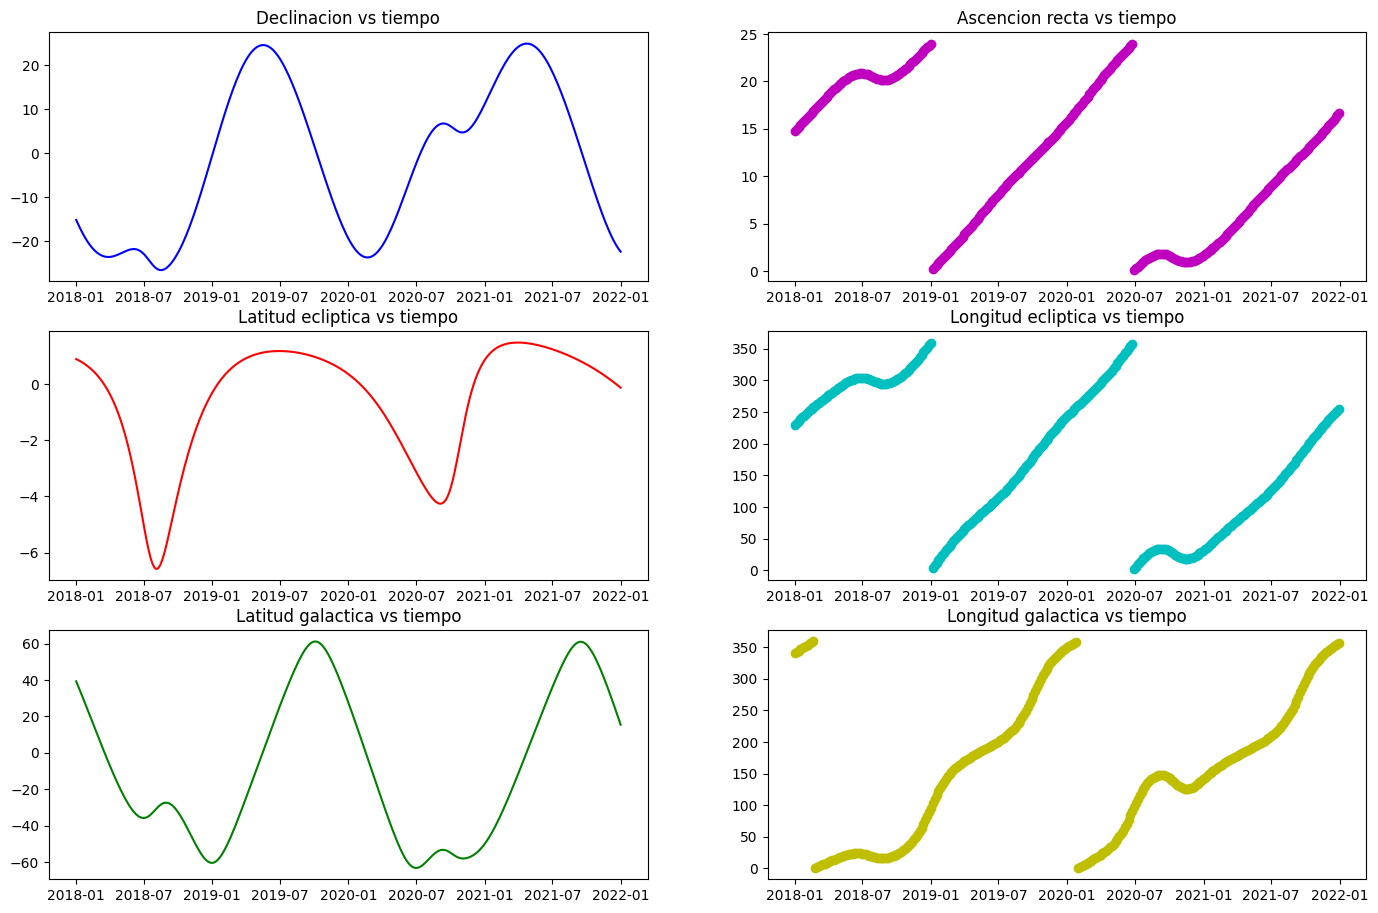

In [ ]:
#mostramos todas las gaficas anteriores para ver mejor

fig, ((ax1, ax2), (ax3, ax4),(ax5,ax6)) = plt.subplots(3, 2, figsize=(17,11))

ax1.plot(df['Date__(UT)__HR:MN'],df['DEC__(ICRF)'],"b")
ax1.set_title('Declinacion vs tiempo')
ax2.plot(df['Date__(UT)__HR:MN'],df['R.A._(ICRF)'],"mo")
ax2.set_title('Ascencion recta vs tiempo')

ax3.plot(df['Date__(UT)__HR:MN'],df['latitud Eclip.'],"r")
ax3.set_title('Latitud ecliptica vs tiempo')
ax4.plot(df['Date__(UT)__HR:MN'],df['longitud Eclip.'],"co")
ax4.set_title('Longitud ecliptica vs tiempo')

ax5.plot(df['Date__(UT)__HR:MN'],df['latitud Galact.'],"g")
ax5.set_title('Latitud galactica vs tiempo')
ax6.plot(df['Date__(UT)__HR:MN'],df['longitud Galact.'],"yo")
ax6.set_title('Longitud galactica vs tiempo')

Teniendo las graficas de cada una de las variables de cada sistema de coordenada, podemos ver el comportamiento con respecto al tiempo de cada uno de los datos. De los cuales se puede apreciar el ligero movimiento o cambio de este de manera inusual, todos cambias aproximadamente al mismo tiempo, a este se le llama el movimiento de retrogradacion, el cual corresponde al movimiento contrario al que se supone que deberia tener por un cierto tiempo hasta que regresa a su movimiento habitual.

\\

Una buena forma para ver cuanto tiempo se demora el movimiento de retrogradacion es tomando una de las graficas por ejemplo la de la latitud galactica y usando los valores de minimo un maximos locales que calculamos anteriormente podemos calcular el tiempo entre un minimo y un maximo local y con esto sabremos cuanto tiempo se demora el movimiento de retrogradacion.


In [ ]:
#traemos los minimos y maximos y las fechas de cada uno


print('maximos',maximosgal)
print('fechas de los maximos',fechasmaxgal)
print('posiciones de los maximos en la tabla',lugaresmax)

print('minimos',minimosgal)
print('fechas de los minimos',fechasmingal)
print('posiciones de los minimos en la tabla',lugaresmin)


maximos [-27.410230011988112, 61.14395081145017, -53.31624739155656, 60.976777727428505]
fechas de los maximos [Timestamp('2018-08-29 00:00:00'), Timestamp('2019-10-03 00:00:00'), Timestamp('2020-09-12 00:00:00'), Timestamp('2021-09-17 00:00:00')]
posiciones de los maximos en la tabla [48, 128, 197, 271]
minimos [-35.829673684936395, -60.48432536146999, -63.269858640145245, -58.061804989420494]
fechas de los minimos [Timestamp('2018-06-30 00:00:00'), Timestamp('2019-01-01 00:00:00'), Timestamp('2020-06-29 00:00:00'), Timestamp('2020-11-06 00:00:00')]
posiciones de los minimos en la tabla [36, 73, 182, 208]


In [ ]:
#el proceso de retrogradacion que ocurre entre el primer minimo y el primer maximo esta dado por

print('Proceso de retrogradacion desde', fechasmingal[0],'hasta',fechasmaxgal[0])



Proceso de retrogradacion desde 2018-06-30 00:00:00 hasta 2018-08-29 00:00:00


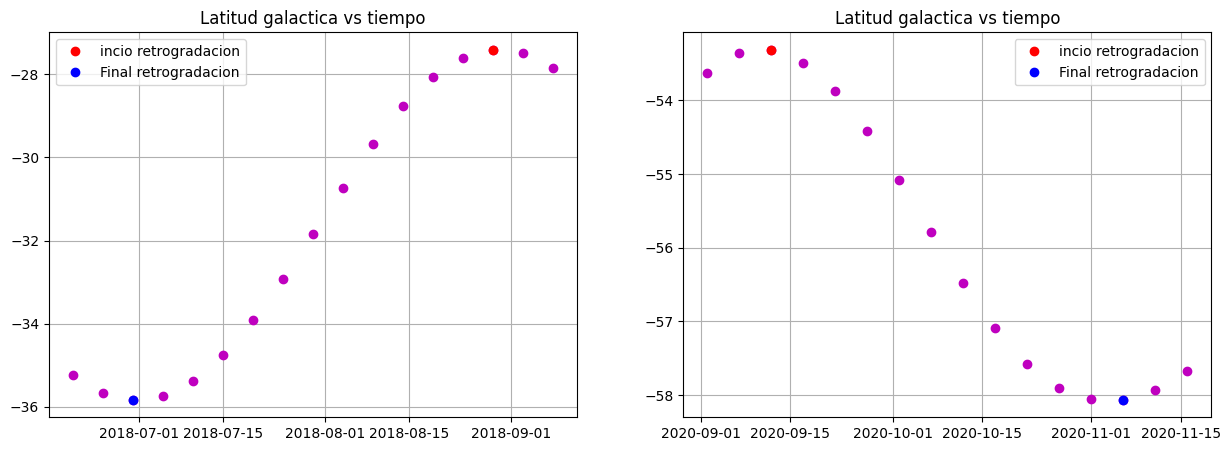

In [ ]:
#graficamos donde se puede apreciar el cambio
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15,5))
#retrogradacion 1
ax1.plot(df['Date__(UT)__HR:MN'][34:51],df['latitud Galact.'][34:51],'mo')
ax1.plot(fechasmaxgal[0],maximosgal[0],"ro",label="incio retrogradacion")
ax1.plot(fechasmingal[0],minimosgal[0],"bo",label="Final retrogradacion")
ax1.set_title("Latitud galactica vs tiempo")
ax1.grid()
ax1.legend()
#Retrogradacion 2
ax2.plot(df['Date__(UT)__HR:MN'][195:211],df['latitud Galact.'][195:211],'mo')
ax2.plot(fechasmaxgal[2],maximosgal[2],"ro",label="incio retrogradacion")
ax2.plot(fechasmingal[3],minimosgal[3],"bo",label="Final retrogradacion")
ax2.set_title("Latitud galactica vs tiempo")
ax2.grid()
ax2.legend()

en las graficas se muestra un acercamiento de los dos casos de retrogradacion que se presentan en la latitud galactica para poder analizar el comportamiento

In [ ]:
rango = df['Date__(UT)__HR:MN'][36:48]
a=0
for i in range(len(rango)): #aqui hacemos un contedio de los dias en que dura la retorgradacion
  a=a + 1

dias= a*5 #o multiplicamos por 5 ya que el salto de un dato y el otro es de 5 dias
print("El fenomeno de la retrogradacion se da a parte de el dia",df['Date__(UT)__HR:MN'][36],'y termina el dia',df['Date__(UT)__HR:MN'][48],'con una duracion de',dias,"dias")

El fenomeno de la retrogradacion se da a parte de el dia 2018-06-30 00:00:00 y termina el dia 2018-08-29 00:00:00 con una duracion de 60 dias


### b) Estime tambien el periodo sinodico del planeta y, a partir de este, el periodo sideral.

El periodo sinodico de un planeta es el periodo que se demora en volver a estar en oposicion, es este caso para un planeta exterior como lo es Marte. O tambien en el momento en que estan en la misma posicion

El paneta tierra y marte vuelven a estar en conjuncion aproximadamente en el punto medio de la retrogradacion de el planeta, asi que para este caso vamos a coger el valor cetral de la retrogradacion y calcuraremos el tiempo en que se demora en volver a estar en ese punto, es decir cuando ocurre la proxima retrogradacon

In [ ]:
#punto medio entre donde se resenta la retrogradacion es en

punto1=fechasmingal[0]
punto2=fechasmaxgal[2]

In [ ]:
P= punto2-punto1
print('El periodo sinodico de marte es de ',P)

El periodo sinodico de marte es de  805 days 00:00:00


Para calcular el perdiodo sinodico usamos la siguiente ecuacion
$$ \frac{1}{T_t}= \frac{1}{P} + \frac{1}{T_p}$$

Despejando $T_p$
$$T_p = \frac{PT_t}{P-T_t}$$

Siendo $P$ el periodo sideral, $T_t$ el periodo de la tierra y $T_p$ el perdiodo sinodico  

In [ ]:
#hacemos la funcion para el calculo del periodo sideral

def sinodico(P,T):
  Tp = (P * T)/(P - T)
  return Tp
#Tiempo sinodico calculado
P=805

#definimos periodo de la tierra
T_t=365.256


#calculamos el periodo sideral
T_m= sinodico(P,T_t)
print('El periodo sideral de marte es',T_m,'dias')


El periodo sideral de marte es 668.6414823169843 dias


### c)Compare los resultados de los apartados (a) y (b) con los reportados en la
literatura. ¿Que tanto difieren?

In [ ]:
#Calculo de errores

#Valor teorico
P_r= 686.971 #Periodo sinodico teorico
T_mr= 686.971  #Periodo sideral teorico


#Para el periodo sinodico
#Error absoluto
E_abs = abs(P - P_r)
print("Error absoluto del periodo sinodico =", E_abs,"dias")

#Error porcentual
E_p = (E_abs/P_r)*100
print("Error porcentual del periodo sinodico =", E_p,"%")



#Para el periodo sideral

#Error absoluto
E_abs = abs(T_m - T_mr)
print("Error absoluto del periodo sideral =", E_abs,"dias")

#Error porcentual
E_p = (E_abs/T_mr)*100
print("Error porcentual del periodo sideral =", E_p,"%")


Error absoluto del periodo sinodico = 118.029 dias
Error porcentual del periodo sinodico = 17.181074601402386 %
Error absoluto del periodo sideral = 18.32951768301575 dias
Error porcentual del periodo sideral = 2.668164694436265 %
